# Chi-Square Test for 2 Categorical Variables

In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 1: Read the Excel file using pandas
# excel_file = '/content/drive/MyDrive/Colab Notebooks/data_v3.xlsx'
excel_file = 'data_v3.xlsx'

#excel_file1 = '/content/drive/MyDrive/Colab Notebooks/updated_file_with_demographic.xlsx'

df_quant = pd.read_excel(excel_file, index_col=0, sheet_name='Quantitative_Likert')
df_demo = pd.read_excel(excel_file, index_col=0, sheet_name='Demographic_Cleaned_v3')
#df_demo = pd.read_excel(excel_file1, index_col=0)

df = df_quant.merge(df_demo, left_index=True, right_index=True)


# List out the columns


In [30]:
# only demographic
#demographic_columns = ['age_generation', 'education', 'internet_familiarity', 'internet_quality', 'study_major']
# desktop_familiarity	laptop_familiarity	smartphone_familiarity	featurephone_familiarity	tablet_familiarity	smartwatch_familiarity	internet_familiarity	internet_quality

# only quantitative
columns_for_existing_app_q = [
'whatsapp_usage' , 'messenger_usage' , 'discord_usage' , 'skype_usage' , 'msteams_usage' , 'slack_usage' , 'instagram_usage' , 'snapchat_usage' , 'telegram_usage' , 'reddit_usage' , 'imo_usage' , 'viber_usage' ,
'whatsapp_ui_organization' , 'messenger_ui_organization' , 'discord_ui_organization' , 'skype_ui_organization' , 'msteams_ui_organization' , 'slack_ui_organization' , 'instagram_ui_organization' , 'snapchat_ui_organization' , 'telegram_ui_organization' , 'reddit_ui_organization' , 'imo_ui_organization' , 'viber_ui_organization' ,
'whatsapp_response_speed' , 'messenger_response_speed' , 'discord_response_speed' , 'skype_response_speed' , 'msteams_response_speed' , 'slack_response_speed' , 'instagram_response_speed' , 'snapchat_response_speed' , 'telegram_response_speed' , 'reddit_response_speed' , 'imo_response_speed' , 'viber_response_speed' ,
'whatsapp_feature_satisfaction' , 'messenger_feature_satisfaction' , 'discord_feature_satisfaction' , 'skype_feature_satisfaction' , 'msteams_feature_satisfaction' , 'slack_feature_satisfaction' , 'instagram_feature_satisfaction' , 'snapchat_feature_satisfaction' , 'telegram_feature_satisfaction' , 'reddit_feature_satisfaction' , 'imo_feature_satisfaction' , 'viber_feature_satisfaction' ,
'whatsapp_privacy_invasion' , 'messenger_privacy_invasion' , 'discord_privacy_invasion' , 'skype_privacy_invasion' , 'msteams_privacy_invasion' , 'slack_privacy_invasion' , 'instagram_privacy_invasion' , 'snapchat_privacy_invasion' , 'telegram_privacy_invasion' , 'reddit_privacy_invasion' , 'imo_privacy_invasion' , 'viber_privacy_invasion' ,
'whatsapp_cyberbullying' , 'messenger_cyberbullying' , 'discord_cyberbullying' , 'skype_cyberbullying' , 'msteams_cyberbullying' , 'slack_cyberbullying' , 'instagram_cyberbullying' , 'snapchat_cyberbullying' , 'telegram_cyberbullying' , 'reddit_cyberbullying' , 'imo_cyberbullying' , 'viber_cyberbullying' ,
'whatsapp_ad_personalization' , 'messenger_ad_personalization' , 'discord_ad_personalization' , 'skype_ad_personalization' , 'msteams_ad_personalization' , 'slack_ad_personalization' , 'instagram_ad_personalization' , 'snapchat_ad_personalization' , 'telegram_ad_personalization' , 'reddit_ad_personalization' , 'imo_ad_personalization' , 'viber_ad_personalization' ,
'whatsapp_misinformation' , 'messenger_misinformation' , 'discord_misinformation' , 'skype_misinformation' , 'msteams_misinformation' , 'slack_misinformation' , 'instagram_misinformation' , 'snapchat_misinformation' , 'telegram_misinformation' , 'reddit_misinformation' , 'imo_misinformation' , 'viber_misinformation' ,
'whatsapp_identity_theft' , 'messenger_identity_theft' , 'discord_identity_theft' , 'skype_identity_theft' , 'msteams_identity_theft' , 'slack_identity_theft' , 'instagram_identity_theft' , 'snapchat_identity_theft' , 'telegram_identity_theft' , 'reddit_identity_theft' , 'imo_identity_theft' , 'viber_identity_theft' ,
'whatsapp_location_tracking' , 'messenger_location_tracking' , 'discord_location_tracking' , 'skype_location_tracking' , 'msteams_location_tracking' , 'slack_location_tracking' , 'instagram_location_tracking' , 'snapchat_location_tracking' , 'telegram_location_tracking' , 'reddit_location_tracking' , 'imo_location_tracking' , 'viber_location_tracking' ,
'whatsapp_data_misuse' , 'messenger_data_misuse' , 'discord_data_misuse' , 'skype_data_misuse' , 'msteams_data_misuse' , 'slack_data_misuse' , 'instagram_data_misuse' , 'snapchat_data_misuse' , 'telegram_data_misuse' , 'reddit_data_misuse' , 'imo_data_misuse' , 'viber_data_misuse' ,
'whatsapp_content_findability' , 'messenger_content_findability' , 'discord_content_findability' , 'skype_content_findability' , 'msteams_content_findability' , 'slack_content_findability' , 'instagram_content_findability' , 'snapchat_content_findability' , 'telegram_content_findability' , 'reddit_content_findability' , 'imo_content_findability' , 'viber_content_findability' ,
'whatsapp_content_loss' , 'messenger_content_loss' , 'discord_content_loss' , 'skype_content_loss' , 'msteams_content_loss' , 'slack_content_loss' , 'instagram_content_loss' , 'snapchat_content_loss' , 'telegram_content_loss' , 'reddit_content_loss' , 'imo_content_loss' , 'viber_content_loss' ,
'whatsapp_login_issues' , 'messenger_login_issues' , 'discord_login_issues' , 'skype_login_issues' , 'msteams_login_issues' , 'slack_login_issues' , 'instagram_login_issues' , 'snapchat_login_issues' , 'telegram_login_issues' , 'reddit_login_issues' , 'imo_login_issues' , 'viber_login_issues' ,
'whatsapp_unintended_sharing' , 'messenger_unintended_sharing' , 'discord_unintended_sharing' , 'skype_unintended_sharing' , 'msteams_unintended_sharing' , 'slack_unintended_sharing' , 'instagram_unintended_sharing' , 'snapchat_unintended_sharing' , 'telegram_unintended_sharing' , 'reddit_unintended_sharing' , 'imo_unintended_sharing' , 'viber_unintended_sharing' ,
'whatsapp_spam_frequency' , 'messenger_spam_frequency' , 'discord_spam_frequency' , 'skype_spam_frequency' , 'msteams_spam_frequency' , 'slack_spam_frequency' , 'instagram_spam_frequency' , 'snapchat_spam_frequency' , 'telegram_spam_frequency' , 'reddit_spam_frequency' , 'imo_spam_frequency' , 'viber_spam_frequency' ,
'whatsapp_missed_notifications' , 'messenger_missed_notifications' , 'discord_missed_notifications' , 'skype_missed_notifications' , 'msteams_missed_notifications' , 'slack_missed_notifications' , 'instagram_missed_notifications' , 'snapchat_missed_notifications' , 'telegram_missed_notifications' , 'reddit_missed_notifications' , 'imo_missed_notifications' , 'viber_missed_notifications' ,
'whatsapp_notification_satisfaction' , 'messenger_notification_satisfaction' , 'discord_notification_satisfaction' , 'skype_notification_satisfaction' , 'msteams_notification_satisfaction' , 'slack_notification_satisfaction' , 'instagram_notification_satisfaction' , 'snapchat_notification_satisfaction' , 'telegram_notification_satisfaction' , 'reddit_notification_satisfaction' , 'imo_notification_satisfaction' , 'viber_notification_satisfaction' ,
'legal_framework_adequacy']


columns_for_omnichannel_q = ['app_availability_comparison' , 'switching_problems' , 'conversation_tracking_difficulty' , 'miscommunication_issues' , 'communication_delays' , 'generational_difference' ,
'unified_app_desire' ,
'others_switching_problems' , 'others_tracking_difficulty' , 'others_miscommunication' , 'others_communication_delays' , 'others_generational_difference' , 'others_unified_desire' ,
'omnichannel_productivity' , 'omnichannel_time_saving' , 'omnichannel_collaboration' , 'omnichannel_communication_gap' , 'omnichannel_app_switching' , 'omnichannel_conversation_tracking' , 'omnichannel_dependency' , 'omnichannel_info_overload' , 'omnichannel_downtime_effect' , 'omnichannel_feature_limitation' , 'omnichannel_adoption_difficulty' , 'omnichannel_work_life_balance' , 'omnichannel_privacy' , 'omnichannel_security' , 'omnichannel_data_loss' ,
'omnichannel_integration' ,
'omnichannel_adoption_likelihood' ,
'omnichannel_adoption_prediction']


# Best choice = 5, Worst = 1
columns_for_positive_q = ['whatsapp_ui_organization', 'messenger_ui_organization', 'discord_ui_organization', 'skype_ui_organization', 'msteams_ui_organization', 'slack_ui_organization', 'instagram_ui_organization', 'snapchat_ui_organization', 'telegram_ui_organization', 'reddit_ui_organization', 'imo_ui_organization', 'viber_ui_organization', 'whatsapp_response_speed', 'messenger_response_speed', 'discord_response_speed', 'skype_response_speed', 'msteams_response_speed', 'slack_response_speed', 'instagram_response_speed', 'snapchat_response_speed', 'telegram_response_speed', 'reddit_response_speed', 'imo_response_speed', 'viber_response_speed', 'whatsapp_feature_satisfaction', 'messenger_feature_satisfaction', 'discord_feature_satisfaction', 'skype_feature_satisfaction', 'msteams_feature_satisfaction', 'slack_feature_satisfaction', 'instagram_feature_satisfaction', 'snapchat_feature_satisfaction', 'telegram_feature_satisfaction', 'reddit_feature_satisfaction', 'imo_feature_satisfaction', 'viber_feature_satisfaction', 'whatsapp_content_findability', 'messenger_content_findability', 'discord_content_findability', 'skype_content_findability', 'msteams_content_findability', 'slack_content_findability', 'instagram_content_findability', 'snapchat_content_findability', 'telegram_content_findability', 'reddit_content_findability', 'imo_content_findability', 'viber_content_findability', 
'whatsapp_notification_satisfaction', 'messenger_notification_satisfaction', 'discord_notification_satisfaction', 'skype_notification_satisfaction', 'msteams_notification_satisfaction', 'slack_notification_satisfaction', 'instagram_notification_satisfaction', 'snapchat_notification_satisfaction', 'telegram_notification_satisfaction', 'reddit_notification_satisfaction', 'imo_notification_satisfaction', 'viber_notification_satisfaction',
'legal_framework_adequacy']

# Best choice = 1, Worst = 5
columns_for_negative_q = [item for item in columns_for_existing_app_q if item not in columns_for_positive_q]

In [22]:
columns_to_test3 = ['age_generation', 'education', 'internet_familiarity', 'internet_quality','whatsapp_ui_organization' , 'messenger_ui_organization' , 'discord_ui_organization' , 'skype_ui_organization' , 'msteams_ui_organization' , 'slack_ui_organization' , 'instagram_ui_organization' , 'snapchat_ui_organization' , 'telegram_ui_organization' , 'reddit_ui_organization' , 'imo_ui_organization' , 'viber_ui_organization' , 'whatsapp_response_speed' , 'messenger_response_speed' , 'discord_response_speed' , 'skype_response_speed' , 'msteams_response_speed' , 'slack_response_speed' , 'instagram_response_speed' , 'snapchat_response_speed' , 'telegram_response_speed' , 'reddit_response_speed' , 'imo_response_speed' , 'viber_response_speed' , 'whatsapp_feature_satisfaction' , 'messenger_feature_satisfaction' , 'discord_feature_satisfaction' , 'skype_feature_satisfaction' , 'msteams_feature_satisfaction' , 'slack_feature_satisfaction' , 'instagram_feature_satisfaction' , 'snapchat_feature_satisfaction' , 'telegram_feature_satisfaction' , 'reddit_feature_satisfaction' , 'imo_feature_satisfaction' , 'viber_feature_satisfaction' , 'whatsapp_content_findability' , 'messenger_content_findability' , 'discord_content_findability' , 'skype_content_findability' , 'msteams_content_findability' , 'slack_content_findability' , 'instagram_content_findability' , 'snapchat_content_findability' , 'telegram_content_findability' , 'reddit_content_findability' , 'imo_content_findability' , 'viber_content_findability']

columns_to_test4 = ['age_generation', 'education', 'internet_familiarity', 'internet_quality',
                    'whatsapp_ui_organization' ,'whatsapp_response_speed' ,'whatsapp_feature_satisfaction' ,'whatsapp_content_findability']

In [31]:
app_list = ['whatsapp', 'messenger', 'discord', 'skype', 'msteams', 'slack', 'instagram', 'snapchat', 'telegram', 'reddit', 'imo', 'viber']
demographic_columns = ['age_generation', 'gender', 'education', 'internet_familiarity', 'internet_quality', 'study_major',
                       'desktop_familiarity','laptop_familiarity','smartphone_familiarity','featurephone_familiarity','tablet_familiarity','smartwatch_familiarity',
                       'devices_used_Android / iPhone / Touchscreen phone','devices_used_Desktop Computer / iMac / Mac mini','devices_used_Feature phone (with physical keyboard having no touchscreen)','devices_used_Laptop / Macbook','devices_used_Mobile phone','devices_used_Smartwatch','devices_used_Tablet / iPad']


omnichannel_questions = [['omnichannel_productivity' , 'omnichannel_time_saving' , 'omnichannel_collaboration' , 'omnichannel_communication_gap' , 'omnichannel_app_switching' , 'omnichannel_conversation_tracking'] ,
                         ['omnichannel_dependency' , 'omnichannel_info_overload' , 'omnichannel_downtime_effect' , 'omnichannel_feature_limitation' , 'omnichannel_adoption_difficulty' ],
                         ['omnichannel_work_life_balance' , 'omnichannel_privacy' , 'omnichannel_security' , 'omnichannel_data_loss' , 'omnichannel_integration'] ,
                         ['omnichannel_adoption_likelihood']]
omnichannel_questions_short = [ 'omnichannel_privacy' , 'omnichannel_security', 'omnichannel_adoption_likelihood']

substrings_of_existing_app_prob = ['privacy_invasion', 'cyberbullying', 'ad_personalization', 'misinformation', 'identity_theft', 'location_tracking', 'data_misuse']


# Function to get a list of column list from a given larger set, a list of substrings to search for.
def get_column_list_for_each_item(list_of_all_columns, list_of_items):
  filtered_items = []
  for i in list_of_items:
    tempList = [item for item in list_of_all_columns if i.lower() in item.lower()]
    filtered_items.append(tempList)
  
  return filtered_items


## horizontal: one app, all question (from substrings_of_existing_app_prob)
horizontal_column_list = get_column_list_for_each_item(columns_for_existing_app_q, app_list)


## vertical: all app, one question (from substrings_of_existing_app_prob)
vertical_column_list = get_column_list_for_each_item(columns_for_existing_app_q, substrings_of_existing_app_prob)

## One Demographic Column x Other Quant Columns

In [8]:
for  demo_column in demographic_columns:
    # print(f"Demographic Column: {demo_column}")
    for quant_column in columns_for_existing_app_q:
        # Step 2: Create a contingency table
        contingency_table = pd.crosstab(df[demo_column], df[quant_column])
        # Step 3: Perform the chi-square test
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        # Step 4: Calculate Cramér's V
        N = df.shape[0]
        degrees_of_freedom_min = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
        if degrees_of_freedom_min == 0:
            continue
        V = (chi2 / N) ** 0.5 / degrees_of_freedom_min

        # Step 5: Display results
        print(f"Demographic Column: {demo_column}")
        print(f"Quant Column '{quant_column}': ")
        print()
        print("Chi-square statistic:", chi2)
        print("P-value:", p)
        print("Degrees of freedom:", dof)
        print("Cramér's V:", V)
        print()

Demographic Column: age_generation
Quant Column 'whatsapp_usage': 

Chi-square statistic: 4.921095549012078
P-value: 0.8411315759786842
Degrees of freedom: 9
Cramér's V: 0.06317559784463324

Demographic Column: age_generation
Quant Column 'messenger_usage': 

Chi-square statistic: 15.740826390590541
P-value: 0.20339713050716182
Degrees of freedom: 12
Cramér's V: 0.11298797526827124

Demographic Column: age_generation
Quant Column 'discord_usage': 

Chi-square statistic: 5.152146934723256
P-value: 0.7411975993121503
Degrees of freedom: 8
Cramér's V: 0.0969625081310897

Demographic Column: age_generation
Quant Column 'skype_usage': 

Chi-square statistic: 14.591864101683424
P-value: 0.06758443423608995
Degrees of freedom: 8
Cramér's V: 0.16317931620352066

Demographic Column: age_generation
Quant Column 'msteams_usage': 

Chi-square statistic: 14.418086444019302
P-value: 0.07149822405219661
Degrees of freedom: 8
Cramér's V: 0.16220473705370925

Demographic Column: age_generation
Quant Co

In [26]:
from queue import PriorityQueue
import heapq

# Dictionary to store aggregate scores for demographic columns
demo_scores = {}
# List to store all relationships for ranking
all_relationships = []

for demo_column in demographic_columns:
    total_score = 0  # Track aggregate score for each demographic column
    relationships_count = 0

    for quant_column in columns_for_existing_app_q:
        # Your existing contingency table and calculations here
        contingency_table = pd.crosstab(df[demo_column], df[quant_column])
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        N = df.shape[0]
        degrees_of_freedom_min = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)

        if degrees_of_freedom_min == 0:
            continue

        V = (chi2 / N) ** 0.5 / degrees_of_freedom_min

        # Decision making
        significance = ""
        strength = ""
        if p < 0.05:
            significance = "Statistically Significant"
            if V > 0.60:
                strength = "Strong"
                score = 5
            elif V > 0.40:
                strength = "Relatively Strong"
                score = 4
            elif V > 0.20:
                strength = "Moderate"
                score = 3
            elif V > 0.10:
                strength = "Weak"
                score = 2
            else:
                strength = "Negligible"
                score = 1
        else:
            significance = "Not Statistically Significant"
            score = 0
            strength = "N/A"

        # Store relationship info
        relationship_info = {
            'demo_column': demo_column,
            'quant_column': quant_column,
            'chi2': chi2,
            'p_value': p,
            'cramers_v': V,
            'significance': significance,
            'strength': strength,
            'score': score
        }

        # Add to our tracking lists
        all_relationships.append(relationship_info)
        total_score += score
        relationships_count += 1

        # Print current relationship analysis
        print(f"Demographic Column: {demo_column}")
        print(f"Quant Column '{quant_column}': ")
        print(f"Chi-square statistic: {chi2}")
        print(f"P-value: {p}")
        print(f"Cramér's V: {V}")
        print(f"Decision: {significance}, Relationship Strength: {strength}")
        print()

    # Calculate average score for this demographic column
    if relationships_count > 0:
        demo_scores[demo_column] = total_score / relationships_count

# Get top 3 demographic columns
top_3_demos = sorted(demo_scores.items(), key=lambda x: x[1], reverse=True)[:3]

print("\nTop 3 Demographic Columns by Overall Relationship Strength:")
for i, (column, score) in enumerate(top_3_demos, 1):
    print(f"{i}. {column} (Average Score: {score:.2f})")

# Get top 5 strongest individual relationships
print("\nTop 5 Strongest Individual Relationships:")
top_relationships = sorted(all_relationships, key=lambda x: (x['score'], x['cramers_v']), reverse=True)[:5]
for i, rel in enumerate(top_relationships, 1):
    print(f"{i}. {rel['demo_column']} vs {rel['quant_column']}")
    print(f"   Significance: {rel['significance']}")
    print(f"   Strength: {rel['strength']}")
    print(f"   Cramér's V: {rel['cramers_v']:.3f}")
    print()

Demographic Column: age_generation
Quant Column 'whatsapp_usage': 
Chi-square statistic: 4.921095549012078
P-value: 0.8411315759786842
Cramér's V: 0.06317559784463324
Decision: Not Statistically Significant, Relationship Strength: N/A

Demographic Column: age_generation
Quant Column 'messenger_usage': 
Chi-square statistic: 15.740826390590541
P-value: 0.20339713050716182
Cramér's V: 0.11298797526827124
Decision: Not Statistically Significant, Relationship Strength: N/A

Demographic Column: age_generation
Quant Column 'discord_usage': 
Chi-square statistic: 5.152146934723256
P-value: 0.7411975993121503
Cramér's V: 0.0969625081310897
Decision: Not Statistically Significant, Relationship Strength: N/A

Demographic Column: age_generation
Quant Column 'skype_usage': 
Chi-square statistic: 14.591864101683424
P-value: 0.06758443423608995
Cramér's V: 0.16317931620352066
Decision: Not Statistically Significant, Relationship Strength: N/A

Demographic Column: age_generation
Quant Column 'msteams

# Heatmap from Cramer's V (EMRD)

In [46]:
import os

# Function to calculate Cramér's V for two categorical variables
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


def calculate_cramers_matrix(data):
    # Calculate Cramér's V for each pair of categorical variables
    variables = data.columns
    length = len(variables)
    calculated_cramers_matrix = np.zeros((len(variables), len(variables)))
    for i in range(len(variables)):
        for j in range(len(variables)):
            confusion_matrix = pd.crosstab(data[variables[i]], data[variables[j]])
            calculated_cramers_matrix[i, j] = cramers_v(confusion_matrix)
    return calculated_cramers_matrix


def calculate_CM_and_plot_heatmap(data, plot_name, folder_path):
  cramers_matrix = calculate_cramers_matrix(data)

  # Adjustments for visibility
  plt.figure(figsize=(12, 10))
  sns.heatmap(cramers_matrix, annot=True, annot_kws={"size": 9}, xticklabels=data.columns, yticklabels=data.columns)

  # Save the heatmap as an image
  #plt.savefig(os.path.join(folder_path, plot_name + ".png"), bbox_inches="tight")

  # Show the plot
  plt.show()

In [ ]:
calculate_CM_and_plot_heatmap(df[columns_for_positive_q[0:10]], app_list[0]+"_")

In [110]:
## horizontal: one problem, all app
pos_prob_list = ['ui_organization', 'response_speed', 'feature_satisfaction', 'content_findability', 'notification_satisfaction', 'legal_framework_adequacy']

horizontal_column_list_pos_q = get_column_list_for_each_item(columns_for_positive_q, pos_prob_list)
folder_path = "D:\\Research\\omnichannel-research\\Heatmaps\\PositiveQ"

# plot per problem
for i in range(len(horizontal_column_list_pos_q)):
  combined_columns = demographic_columns[0:6] + horizontal_column_list_pos_q[i]
  data = df[combined_columns]
  #calculate_CM_and_plot_heatmap(data, pos_prob_list[i], folder_path)

In [116]:
## horizontal: one problem, all app
neg_prob_list = ['ad_personalization', 'content_loss', 'cyberbullying', 'data_misuse', 'identity_theft', 'location_tracking', 'login_issues', 'misinformation', 'missed_notifications', 'privacy_invasion', 'spam_frequency', 'unintended_sharing'] 
horizontal_column_list_neg_q = get_column_list_for_each_item(columns_for_negative_q, neg_prob_list)
folder_path = "D:\\Research\\omnichannel-research\\Heatmaps\\NegativeQ"

# plot per problem
for i in range(len(horizontal_column_list_neg_q)):
  combined_columns = demographic_columns[0:6] + horizontal_column_list_neg_q[i]
  data = df[combined_columns]
  #calculate_CM_and_plot_heatmap(data, neg_prob_list[i], folder_path)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [ ]:
## vertical: one app, all problem
vertical_column_list_pos_q = get_column_list_for_each_item(columns_for_positive_q, app_list)
folder_path = "D:\\Research\\omnichannel-research\\Heatmaps\\PositiveQ\\PerApp"
#vertical_column_list_pos_q

# plot per app
for i in range(len(vertical_column_list_pos_q)):
  combined_columns = demographic_columns[0:6] + vertical_column_list_pos_q[i]
  data = df[combined_columns]
  calculate_CM_and_plot_heatmap(data, app_list[i], folder_path)

In [ ]:
## vertical: one app, all problem
vertical_column_list_neg_q = get_column_list_for_each_item(columns_for_negative_q, app_list)
folder_path = "D:\\Research\\omnichannel-research\\Heatmaps\\NegativeQ\\PerApp"
#vertical_column_list_neg_q

# plot per app
for i in range(len(vertical_column_list_neg_q)):
  combined_columns = demographic_columns[0:6] + vertical_column_list_neg_q[i]
  data = df[combined_columns]
  calculate_CM_and_plot_heatmap(data, app_list[i], folder_path)

# cramers_matrix

In [49]:
cramers_m = calculate_cramers_matrix(data)
variables = data.columns

matrix_to_save = np.vstack([variables, cramers_m])
new_column = variables.insert(0, "")

matrix_to_save = np.column_stack([new_column, matrix_to_save])
matrix = pd.DataFrame(matrix_to_save)

# Specify the Excel file name
excel_file = "output.xlsx"
with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    matrix.to_excel(writer, index=False, header=False)

In [ ]:
# Adjustments for visibility
plt.figure(figsize=(12, 10))
sns.heatmap(cramers_m, annot=True, annot_kws={"size": 7}, xticklabels=variables, yticklabels=variables)

# Save the heatmap as an image
plt.savefig("heatmap.png", bbox_inches="tight")

# Show the plot
plt.show()

# Network Graph

In [ ]:
import pandas as pd

# Open Dataset
path = "output.xlsx"
df1 = pd.read_excel(path, index_col=0, sheet_name='Sheet1')

column_names = list(df1.columns.values)
att_names=list(df1.columns.values)
size_col=len(column_names)
size_att=len(att_names)

i=0
while(i<size_att):
    print("G.add_node(\""+ att_names[i] +"\")")
    i=i+1

for row in range(size_col):
    for col in range(row):
        node1 = column_names[row]
        node2 = column_names[col]
        value = df1.iloc[row, col]
        
        if(value>=0.5 and value <=1):
            if(value>=0.5 and value<0.65):
                #print(value)
                print("G.add_edge(\"" + node1 + "\" , \"" + node2 + "\" , color=\'g\',weight=0.5)")
            elif(value>=0.65 and value<0.8):
                ##print(value)
                print("G.add_edge(\"" + node1 + "\" , \"" + node2 + "\" , color=\'g\',weight=1.5)")
            elif (value>=0.8):
                print("G.add_edge(\"" + node1 + "\" , \"" + node2 + "\" , color=\'g\',weight=2.5)")
   

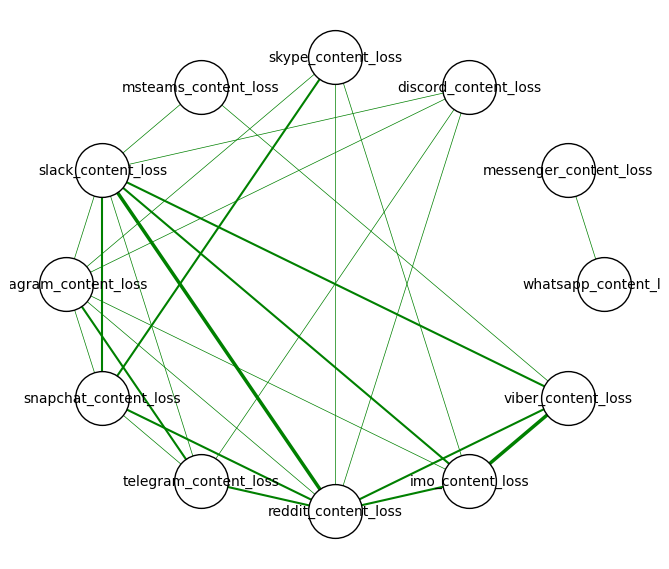

<Figure size 650x550 with 0 Axes>

In [102]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import clique

plt.rcParams["figure.figsize"] = [6.50, 5.50]
plt.rcParams["figure.autolayout"] = True

G = nx.Graph()

#G.add_node("gender")
#G.add_node("education")
#G.add_node("internet_familiarity")
#G.add_node("internet_quality")
#G.add_node("study_major")
G.add_node("whatsapp_content_loss")
G.add_node("messenger_content_loss")
G.add_node("discord_content_loss")
G.add_node("skype_content_loss")
G.add_node("msteams_content_loss")
G.add_node("slack_content_loss")
G.add_node("instagram_content_loss")
G.add_node("snapchat_content_loss")
G.add_node("telegram_content_loss")
G.add_node("reddit_content_loss")
G.add_node("imo_content_loss")
G.add_node("viber_content_loss")


G.add_edge("messenger_content_loss" , "whatsapp_content_loss" , color='g',weight=0.5)
G.add_edge("slack_content_loss" , "discord_content_loss" , color='g',weight=0.5)
G.add_edge("slack_content_loss" , "msteams_content_loss" , color='g',weight=0.5)
G.add_edge("instagram_content_loss" , "discord_content_loss" , color='g',weight=0.5)
G.add_edge("instagram_content_loss" , "skype_content_loss" , color='g',weight=0.5)
G.add_edge("instagram_content_loss" , "slack_content_loss" , color='g',weight=0.5)
G.add_edge("snapchat_content_loss" , "skype_content_loss" , color='g',weight=1.5)
G.add_edge("snapchat_content_loss" , "slack_content_loss" , color='g',weight=1.5)
G.add_edge("snapchat_content_loss" , "instagram_content_loss" , color='g',weight=0.5)
G.add_edge("telegram_content_loss" , "discord_content_loss" , color='g',weight=0.5)
G.add_edge("telegram_content_loss" , "slack_content_loss" , color='g',weight=0.5)
G.add_edge("telegram_content_loss" , "instagram_content_loss" , color='g',weight=1.5)
G.add_edge("telegram_content_loss" , "snapchat_content_loss" , color='g',weight=0.5)
G.add_edge("reddit_content_loss" , "discord_content_loss" , color='g',weight=0.5)
G.add_edge("reddit_content_loss" , "skype_content_loss" , color='g',weight=0.5)
G.add_edge("reddit_content_loss" , "slack_content_loss" , color='g',weight=2.5)
G.add_edge("reddit_content_loss" , "instagram_content_loss" , color='g',weight=0.5)
G.add_edge("reddit_content_loss" , "snapchat_content_loss" , color='g',weight=1.5)
G.add_edge("reddit_content_loss" , "telegram_content_loss" , color='g',weight=1.5)
G.add_edge("imo_content_loss" , "skype_content_loss" , color='g',weight=0.5)
G.add_edge("imo_content_loss" , "slack_content_loss" , color='g',weight=1.5)
G.add_edge("imo_content_loss" , "instagram_content_loss" , color='g',weight=0.5)
G.add_edge("imo_content_loss" , "reddit_content_loss" , color='g',weight=1.5)
G.add_edge("viber_content_loss" , "msteams_content_loss" , color='g',weight=0.5)
G.add_edge("viber_content_loss" , "slack_content_loss" , color='g',weight=1.5)
G.add_edge("viber_content_loss" , "reddit_content_loss" , color='g',weight=1.5)
G.add_edge("viber_content_loss" , "imo_content_loss" , color='g',weight=2.5)


colors = nx.get_edge_attributes(G, 'color').values()
weights = list(nx.get_edge_attributes(G, 'weight').values())

pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, font_size=10, node_size=1500, node_color='white',edgecolors='black',edge_color=colors, width=weights)
plt.show()
folder_path = "D:\\Research\\omnichannel-research\\Graphs\\NegativeQ"
plt.savefig(os.path.join(folder_path, neg_prob_list[1] + ".png"), bbox_inches="tight")

In [122]:
# plot per problem
def plot_and_save_graph(main_df, list_of_column_list, issue_name_list, folder_path):
    for index in range(len(list_of_column_list)):
        combined_columns = list_of_column_list[index]
        main_data = main_df[combined_columns]

        cramers_m = calculate_cramers_matrix(main_data)
        variables = main_data.columns

        matrix_to_save = np.vstack([variables, cramers_m])
        new_column = variables.insert(0, "")

        matrix_to_save = np.column_stack([new_column, matrix_to_save])
        matrix = pd.DataFrame(matrix_to_save)
        
        excel_file = "temp_output.xlsx"
        with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
            matrix.to_excel(writer, index=False, header=False)

        df1 = pd.read_excel(excel_file, index_col=0, sheet_name='Sheet1')

        plt.rcParams["figure.figsize"] = [6.50, 5.50]
        plt.rcParams["figure.autolayout"] = True

        G = nx.Graph()

        column_names = list(df1.columns.values)
        att_names=list(df1.columns.values)
        size_col=len(column_names)
        size_att=len(att_names)

        i=0
        while(i<size_att):
            G.add_node(att_names[i])
            i=i+1

        for row in range(size_col):
            for col in range(row):
                node1 = column_names[row]
                node2 = column_names[col]
                value = df1.iloc[row, col]
                
                if(value>=0.5 and value <=1):
                    if(value>=0.5 and value<0.65):
                        G.add_edge(node1 , node2 , color='g',weight=0.5)
                    elif(value>=0.65 and value<0.8):
                        G.add_edge(node1, node2, color='g',weight=1.5)
                    elif (value>=0.8):
                        G.add_edge(node1, node2, color='g',weight=2.5)

        colors = nx.get_edge_attributes(G, 'color').values()
        weights = list(nx.get_edge_attributes(G, 'weight').values())

        pos = nx.circular_layout(G)
        nx.draw(G, pos, with_labels=True, font_size=10, node_size=1500, node_color='white',edgecolors='black',edge_color=colors, width=weights)
        plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)

        plt.show()

<class 'pandas.core.frame.DataFrame'>


C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


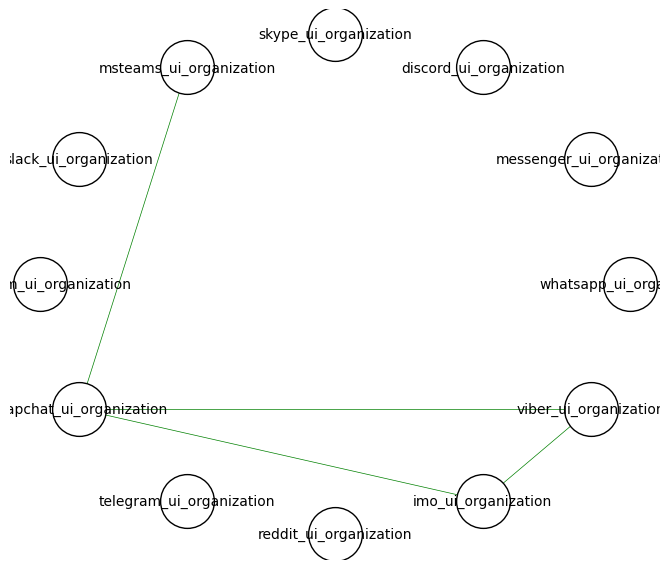

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


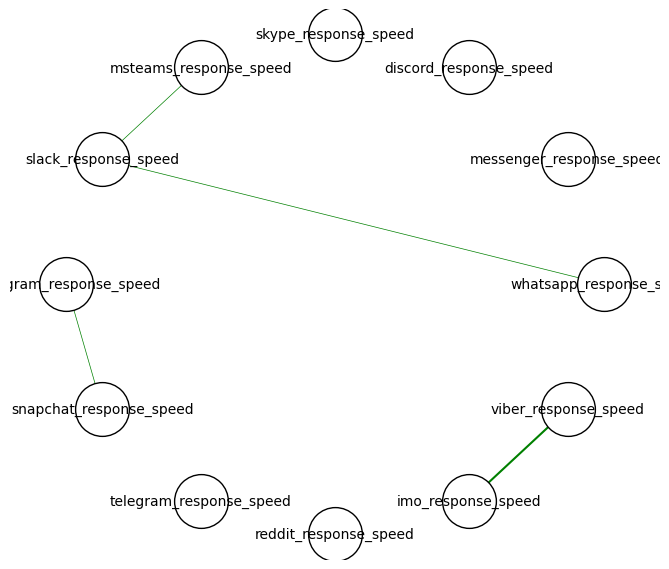

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


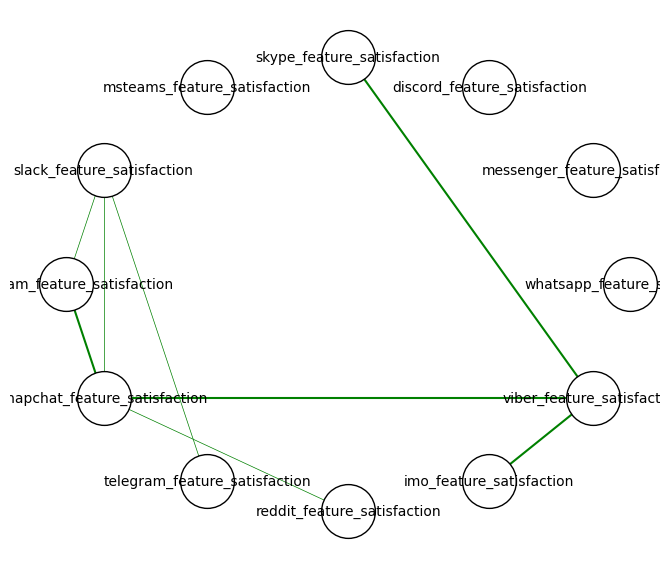

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


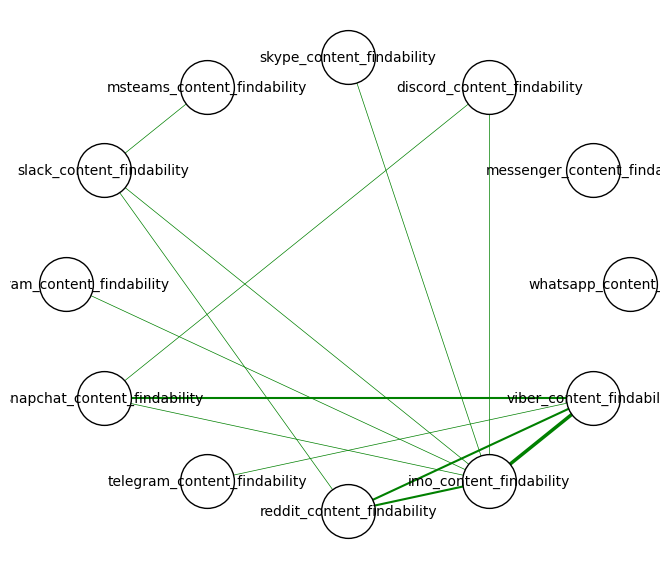

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


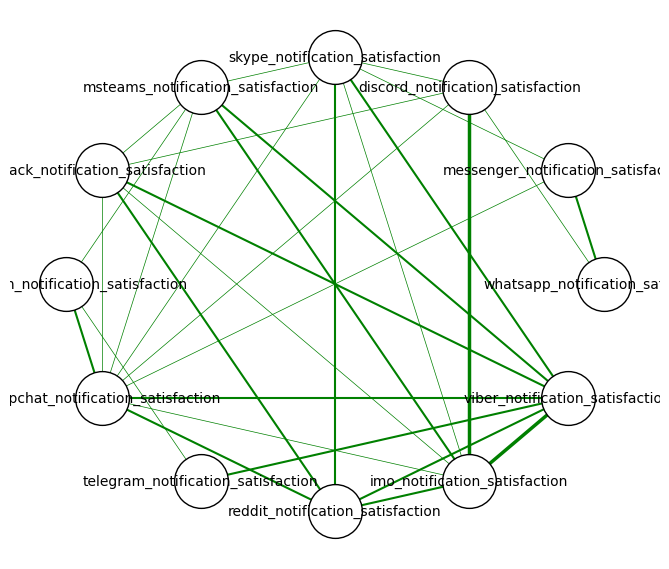

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


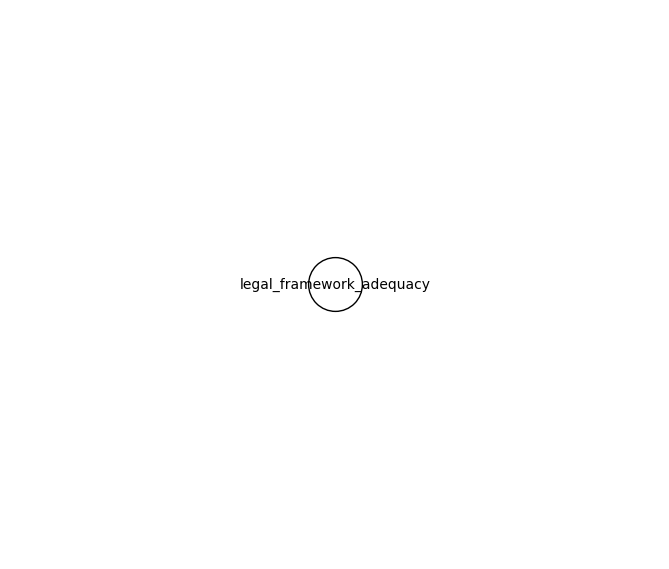

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


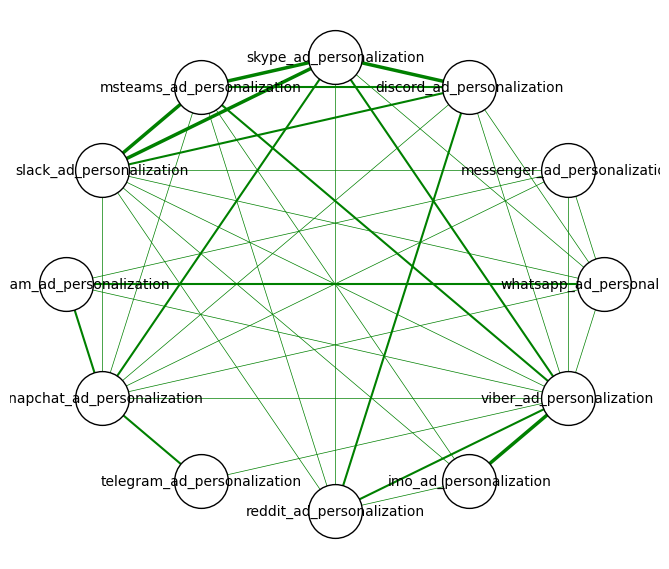

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


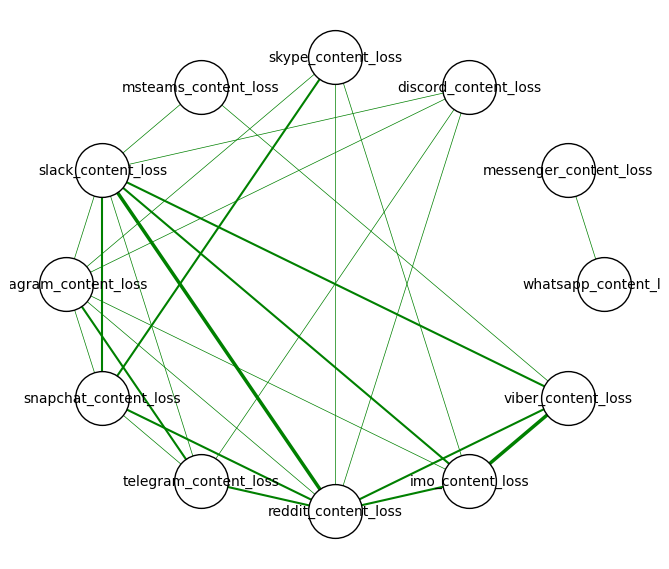

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


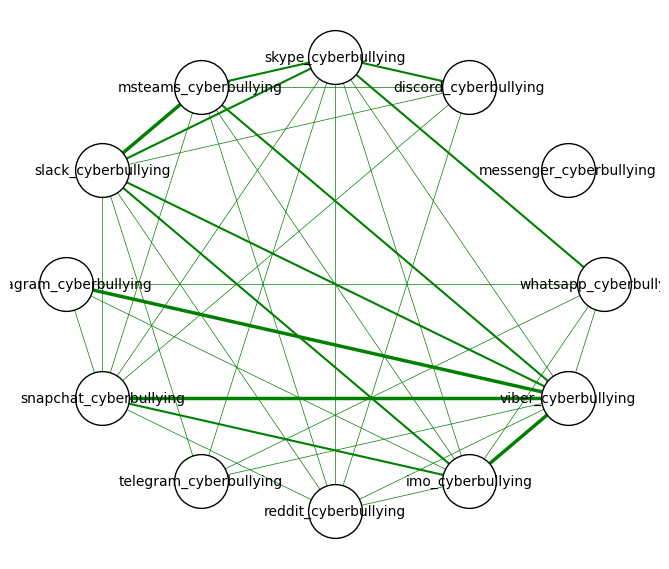

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


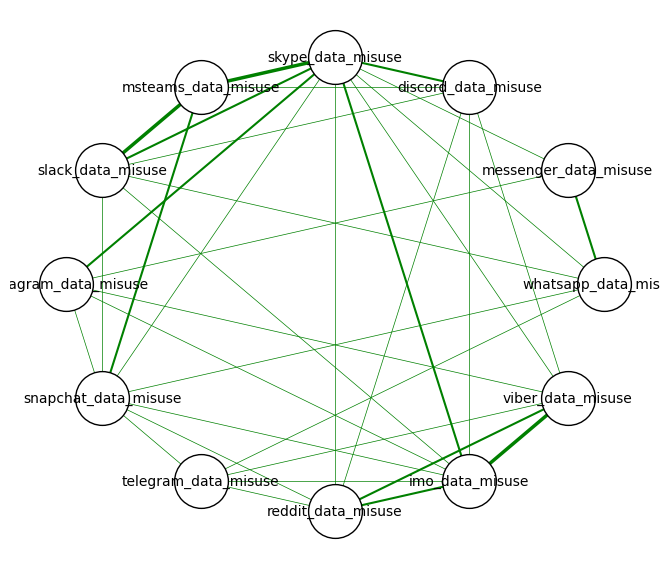

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


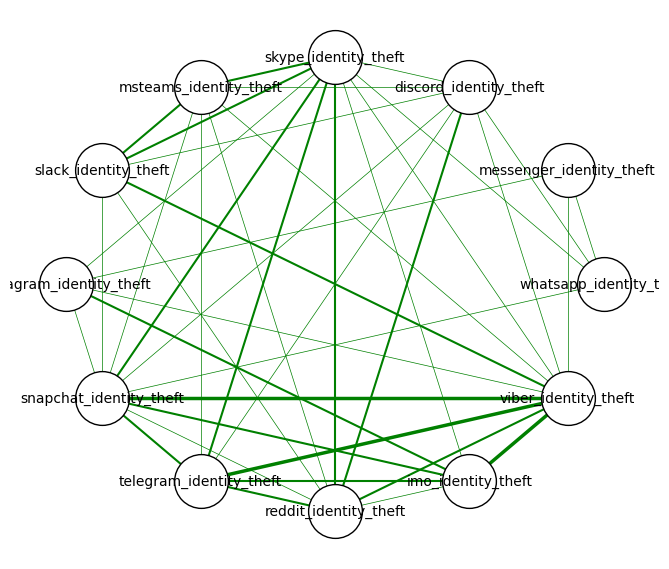

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


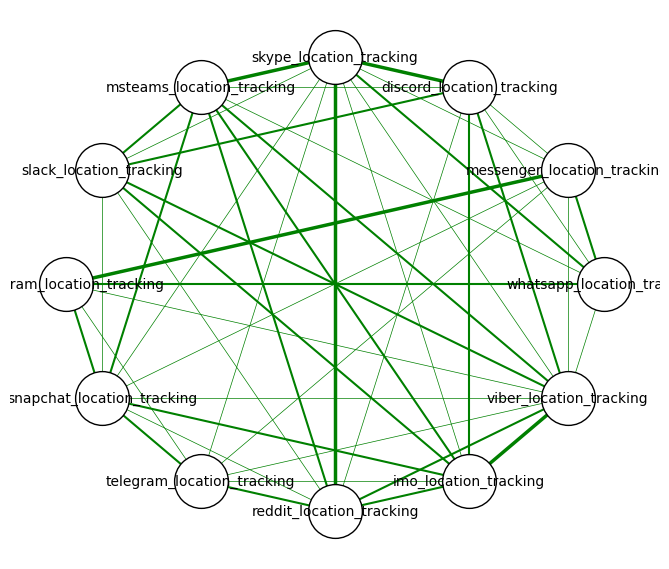

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


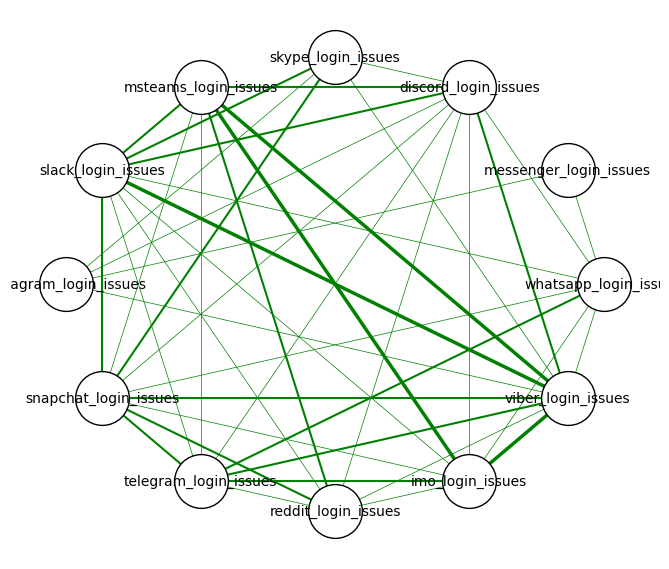

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


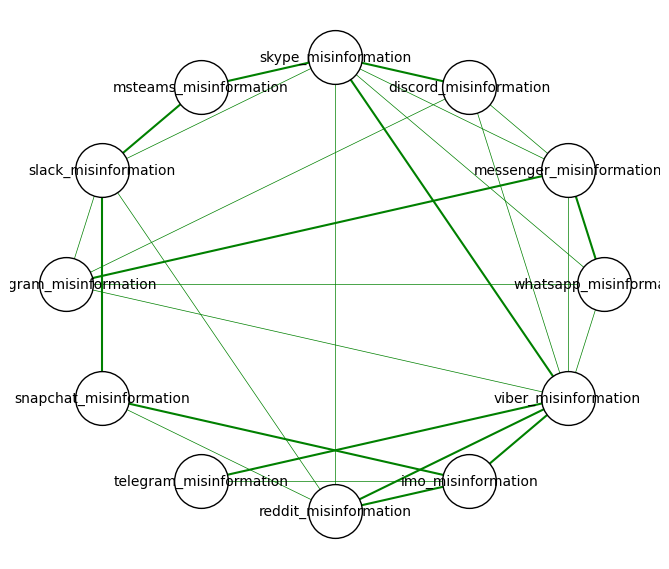

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


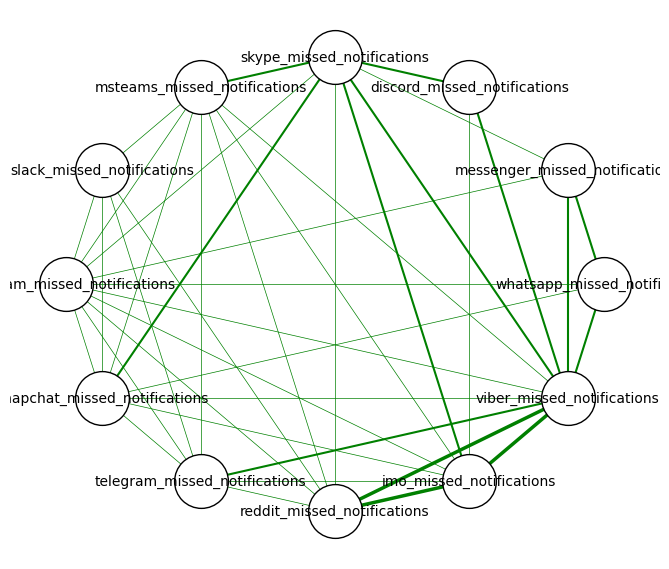

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


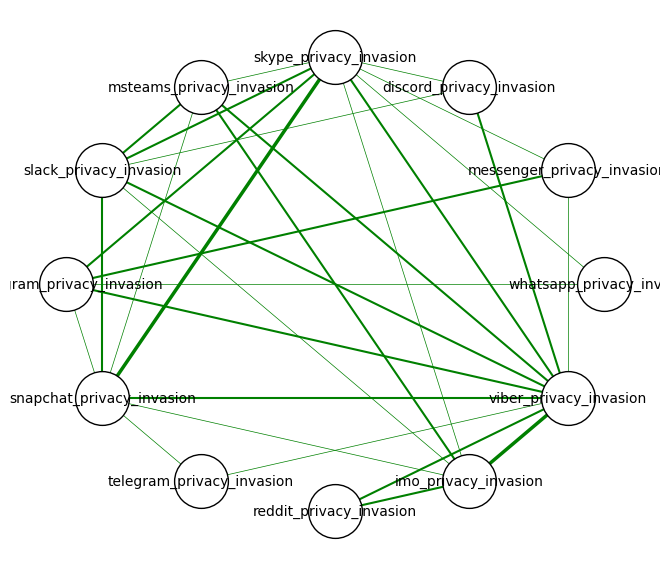

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


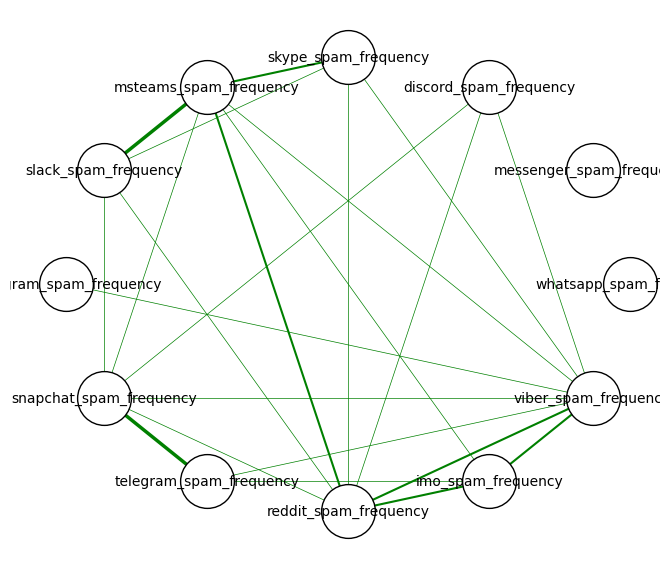

C:\Users\hp\AppData\Local\Temp\ipykernel_18676\1875556755.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(os.path.join(folder_path, issue_name_list[index] + ".png"), bbox_inches="tight", dpi=300)
C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


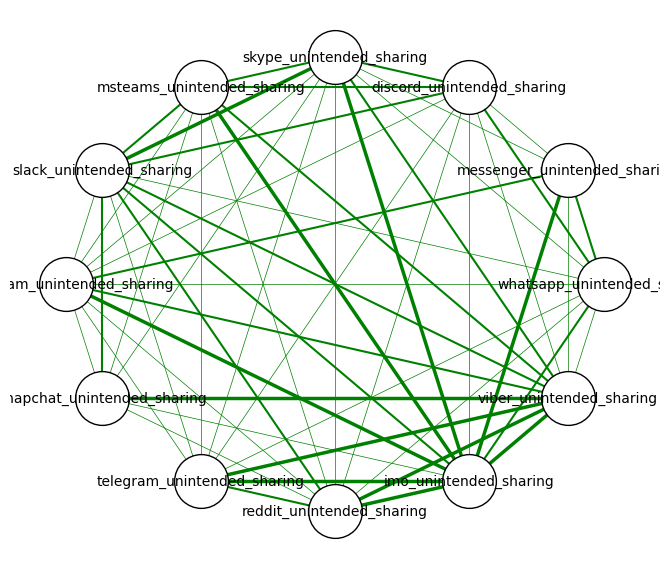

In [123]:
folder_path = "D:\\Research\\omnichannel-research\\Graphs\\PositiveQ"
plot_and_save_graph(df, horizontal_column_list_pos_q, pos_prob_list, folder_path)

folder_path = "D:\\Research\\omnichannel-research\\Graphs\\NegativeQ"
plot_and_save_graph(df, horizontal_column_list_neg_q, neg_prob_list, folder_path)

Maximal Cliques: 0
['T.Adp']
['FA', 'IPLMD', 'BCE']
['FA', 'IPLMD', 'IP']
['FA', 'BCG', 'IP']
['FA', 'BCG', 'EPI']
['ESM', 'IDADM', 'IKSCW', 'IPLMD']
['ESM', 'IDADM', 'OSCM']
['ESM', 'IDADM', 'BCG']
['ESM', 'BCE', 'IKSCW', 'IPLMD']
['ESM', 'BCE', 'OSCM']
['ESM', 'EPI', 'BCG']
['IP', 'IDADM', 'IKSCW', 'IPLMD']
['IP', 'IDADM', 'OSCM']
['IP', 'IDADM', 'BCG']
['IOE', 'IKSCW']
['IOE', 'OSCM']


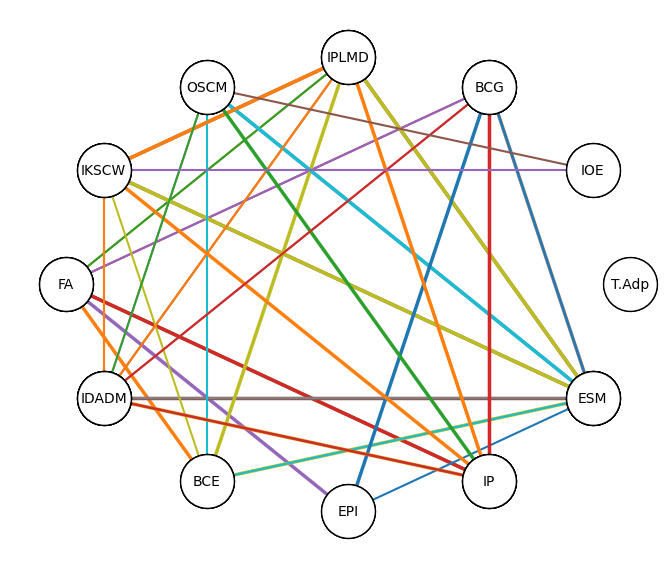

In [ ]:
#Maximal Clique
import matplotlib.colors as mcolors

colors = nx.get_edge_attributes(G, 'color').values()
weights = list(nx.get_edge_attributes(G, 'weight').values())

# Find all maximal cliques
maximal_cliques = list(nx.find_cliques(G))
sel_maximal_cliques=[]

# Display maximal cliques and the nodes that they consist of
required_cliques=0
print("Maximal Cliques:",required_cliques)
for clique in maximal_cliques:
  if len(clique)>required_cliques:
    sel_maximal_cliques.append(clique)
    print(clique)

# Draw the graph
pos = nx.circular_layout(G)

# Draw the graph with node labels
nx.draw(G, pos, with_labels=True, font_size=10, node_size=1500, node_color='white',edgecolors='black',edge_color='white', width=weights)

# Define a list of colors to cycle through, here we take colors from matplotlib's tableau palette
color_list = list(mcolors.TABLEAU_COLORS.values())

# Highlight each maximal clique with a different color
for i, clique in enumerate(sel_maximal_cliques):
    color = color_list[i % len(color_list)]  # Cycle through the color list
    nx.draw_networkx_nodes(G, pos, label=clique, nodelist=clique,node_size=1500, node_color='white',edgecolors='black')
    subgraph = G.subgraph(clique)
    nx.draw_networkx_edges(G, pos, edgelist=subgraph.edges(), edge_color=color,width=weights)

plt.show()

['ESM', 'IDADM', 'IKSCW', 'IPLMD']


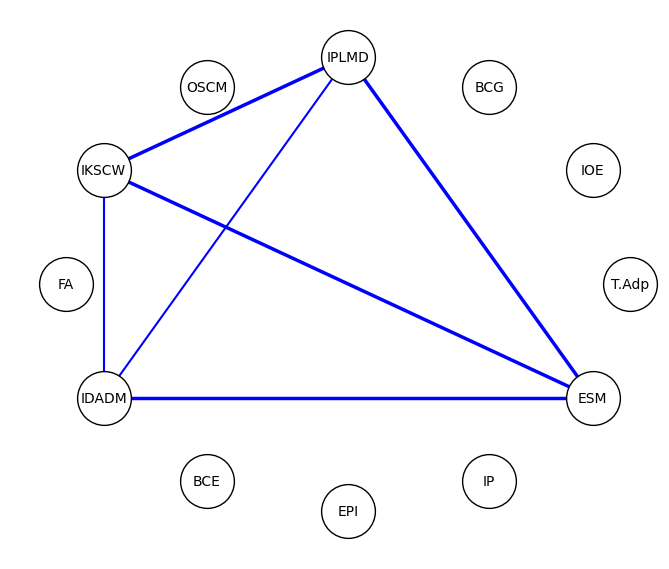

In [ ]:
#Maximum Clique
colors = nx.get_edge_attributes(G, 'color').values()
weights = list(nx.get_edge_attributes(G, 'weight').values())

# Find all maximal cliques
maximal_cliques = list(nx.find_cliques(G))
maximum_clique=list(max(maximal_cliques, key=len))
print(maximum_clique)

# Draw the graph
pos = nx.circular_layout(G)

# Draw the graph with node labels
nx.draw(G, pos, with_labels=True, font_size=10, node_size=1500, node_color='white',edgecolors='black',edge_color='white', width=weights)
subgraph = G.subgraph(maximum_clique)
nx.draw_networkx_edges(G, pos, edgelist=subgraph.edges(), edge_color='blue',width=weights)

plt.show()